# Capstone 3 — Step 2: Data Wrangling
**Predicting Churn and Customer Lifetime Value in a Non-Contractual E-Commerce Setting**

**Student:** Justin Ali · Springboard Data Science Career Track  
**Dataset:** UCI Online Retail II (Dec 2009 – Dec 2011)  
**Notebook:** `01_data_wrangling.ipynb`

---

## Purpose

This notebook covers the full data wrangling pipeline for the Capstone 3 project. It performs:

1. **Data Acquisition** — Download and load the raw UCI Online Retail II dataset
2. **Initial Exploration** — Understand shape, types, and missingness before any cleaning
3. **Data Cleaning** — Remove invalid records (missing customer IDs, cancellations, non-product rows, non-positive values)
4. **Feature Engineering** — Aggregate to customer-level RFM, tenure, behavioral diversity, and temporal pattern features
5. **Time-Based Split** — Define calibration, holdout, and test periods without any data leakage
6. **Export** — Save the cleansed transaction file and the customer-level feature table

All decisions are documented inline. The resulting datasets feed directly into `02_clv_probabilistic.ipynb` (BG/NBD + Gamma-Gamma) and `03_clv_supervised.ipynb` (gradient boosting churn model).

---
## 0. Setup & Imports

In [1]:
import os
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = '../data/raw/'
OUTPUT_DIR = '../data/processed/'

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RAW_ZIP  = os.path.join(DATA_DIR, 'online_retail_II.zip')
RAW_XLSX = os.path.join(DATA_DIR, 'online_retail_II.xlsx')

print('Setup complete.')

Setup complete.


---
## 1. Data Acquisition

The **UCI Online Retail II** dataset contains all transactions for a UK-based, non-store online retailer between December 2009 and December 2011. It is the de-facto standard benchmark dataset for non-contractual CLV work and is the same dataset used in the `lifetimes` library tutorials.

- **Source:** [UCI ML Repository — Dataset #502](https://archive.ics.uci.edu/dataset/502/online+retail+ii)
- **Size:** ~1 million rows, 8 columns, ~5,800 unique customers
- **Key columns:** `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, `Country`

The cell below attempts an automatic download. If that fails (e.g. on a restricted network), follow the manual instructions printed below.

In [2]:
UCI_URL = 'https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip'

def download_dataset():
    """Download and unzip the UCI Online Retail II dataset."""
    if os.path.exists(RAW_XLSX):
        print(f'✓ Dataset already present at: {RAW_XLSX}')
        return True

    print('Attempting automatic download from UCI ML Repository...')
    try:
        urllib.request.urlretrieve(UCI_URL, RAW_ZIP)
        print(f'  Downloaded zip ({os.path.getsize(RAW_ZIP) / 1e6:.1f} MB)')

        with zipfile.ZipFile(RAW_ZIP, 'r') as z:
            xlsx_files = [f for f in z.namelist() if f.endswith('.xlsx')]
            if not xlsx_files:
                raise FileNotFoundError('No .xlsx found inside zip.')
            z.extract(xlsx_files[0], DATA_DIR)
            # Rename to our expected filename if needed
            extracted = os.path.join(DATA_DIR, xlsx_files[0])
            if extracted != RAW_XLSX:
                os.rename(extracted, RAW_XLSX)

        print(f'✓ Extracted to: {RAW_XLSX}')
        return True

    except Exception as e:
        print(f'\n⚠ Automatic download failed: {e}')
        print('\n── Manual Download Instructions ─────────────────────────────────────')
        print('1. Visit: https://archive.ics.uci.edu/dataset/502/online+retail+ii')
        print('2. Click "Download" to get online_retail_II.zip')
        print(f'3. Unzip it and place "online_retail_II.xlsx" at:')
        print(f'   {os.path.abspath(RAW_XLSX)}')
        print('4. Re-run this cell.')
        return False

success = download_dataset()

Attempting automatic download from UCI ML Repository...
  Downloaded zip (45.6 MB)
✓ Extracted to: ../data/raw/online_retail_II.xlsx


In [3]:
assert os.path.exists(RAW_XLSX), (
    f'Dataset not found at {RAW_XLSX}. '
    'Please follow the manual download instructions above.'
)

print('Loading Year 2009-2010 sheet...')
df_0910 = pd.read_excel(RAW_XLSX, sheet_name='Year 2009-2010', engine='openpyxl')
print(f'  Shape: {df_0910.shape}')

print('Loading Year 2010-2011 sheet...')
df_1011 = pd.read_excel(RAW_XLSX, sheet_name='Year 2010-2011', engine='openpyxl')
print(f'  Shape: {df_1011.shape}')

df_raw = pd.concat([df_0910, df_1011], ignore_index=True)
print(f'\n✓ Combined shape: {df_raw.shape}')
print(f'  Columns: {list(df_raw.columns)}')

Loading Year 2009-2010 sheet...
  Shape: (525461, 8)
Loading Year 2010-2011 sheet...
  Shape: (541910, 8)

✓ Combined shape: (1067371, 8)
  Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


---
## 2. Initial Exploration

Before any cleaning, we take stock of what we have: data types, missingness, value ranges, and a sample of rows. This establishes a baseline so we can document what was changed and why.

In [4]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== dtypes & non-null counts ===')
df_raw.info()
print()

# ── Sample rows ───────────────────────────────────────────────────────────────
print('\n=== Sample rows ===')
df_raw.head(5)

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


=== Sample rows ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085.0000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,13085.0000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,13085.0000,United Kingdom


In [5]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print('=== Missing Values ===')
print(pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
      .query('Count > 0').to_string())
print()

# ── Numeric summary ───────────────────────────────────────────────────────────
print('\n=== Numeric Summary ===')
df_raw.describe()

=== Missing Values ===
              Count  Pct (%)
Description    4382   0.4100
Customer ID  243007  22.7700


=== Numeric Summary ===


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.0000,1067371,1067371.0000,824364.0000
mean,9.9389,2011-01-02 21:13:55.394028544,4.6494,15324.6385
min,-80995.0000,2009-12-01 07:45:00,-53594.3600,12346.0000
25%,1.0000,2010-07-09 09:46:00,1.2500,13975.0000
50%,3.0000,2010-12-07 15:28:00,2.1000,15255.0000
75%,10.0000,2011-07-22 10:23:00,4.1500,16797.0000
max,80995.0000,2011-12-09 12:50:00,38970.0000,18287.0000
std,172.7058,NaN,123.5531,1697.4645


In [6]:
# ── Date range ────────────────────────────────────────────────────────────────
print('Date range (raw):')
print(f'  Min: {df_raw["InvoiceDate"].min()}')
print(f'  Max: {df_raw["InvoiceDate"].max()}')
print(f'  Unique invoice dates: {df_raw["InvoiceDate"].nunique():,}')

# ── Key cardinality ───────────────────────────────────────────────────────────
print()
print(f'Unique invoices    : {df_raw["Invoice"].nunique():,}')
print(f'Unique customers   : {df_raw["Customer ID"].nunique():,}')
print(f'Unique stock codes : {df_raw["StockCode"].nunique():,}')
print(f'Unique countries   : {df_raw["Country"].nunique():,}')

# ── Countries distribution ────────────────────────────────────────────────────
print()
print('Top 10 countries by row count:')
print(df_raw['Country'].value_counts().head(10).to_string())

Date range (raw):
  Min: 2009-12-01 07:45:00
  Max: 2011-12-09 12:50:00
  Unique invoice dates: 47,635

Unique invoices    : 53,628
Unique customers   : 5,942
Unique stock codes : 5,305
Unique countries   : 43

Top 10 countries by row count:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913


In [7]:
# ── Spot-check cancellations ──────────────────────────────────────────────────
cancellations = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
print(f'Cancellation rows (Invoice starts with C): {len(cancellations):,} '
      f'({len(cancellations)/len(df_raw)*100:.1f}%)')

# ── Spot-check non-product stock codes ────────────────────────────────────────
non_product_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT',
                     'CRUK', 'AMAZONFEE', 'DCGSSBOY', 'DCGSSGIRL']
non_product_mask = df_raw['StockCode'].astype(str).str.upper().isin(
    [c.upper() for c in non_product_codes]
)
print(f'Non-product stock code rows: {non_product_mask.sum():,}')

# ── Negative / zero values ────────────────────────────────────────────────────
print(f'Rows with Quantity <= 0 : {(df_raw["Quantity"] <= 0).sum():,}')
print(f'Rows with Price <= 0    : {(df_raw["Price"] <= 0).sum():,}')

Cancellation rows (Invoice starts with C): 19,494 (1.8%)
Non-product stock code rows: 5,399
Rows with Quantity <= 0 : 22,950
Rows with Price <= 0    : 6,207


---
## 3. Data Cleaning

We apply the following cleaning steps in sequence, logging row counts at each step so the impact of every decision is transparent.

| Step | Rule | Rationale |
|------|------|-----------|
| 3.1 | Drop rows with missing `Customer ID` | Cannot be attributed to a customer; no RFM aggregation possible |
| 3.2 | Remove cancellation invoices (Invoice starts with `C`) | Cancellations reverse a prior purchase; including them would distort frequency and monetary value |
| 3.3 | Remove non-product `StockCode` rows | Codes like `POST`, `BANK CHARGES`, `M` (manual) are not merchandise and inflate revenue |
| 3.4 | Remove rows with `Quantity ≤ 0` | After removing cancellations, remaining negatives are data errors |
| 3.5 | Remove rows with `Price ≤ 0` | Zero-price and negative-price records cannot contribute valid CLV signal |
| 3.6 | Parse `InvoiceDate` to datetime | Required for all time-based feature engineering and train/test splits |
| 3.7 | Compute `Revenue` = `Quantity × Price` | Core monetary field used throughout |
| 3.8 | Standardize column names | Snake_case throughout for consistency |

> **Design note on cancellations:** Rather than discarding them entirely, we *retain them as a behavioral feature* (customer return rate) in the feature engineering step. Dropping them here only removes them from the CLV-relevant transaction log.

In [8]:
df = df_raw.copy()
steps_log = []

def log_step(step_name, df_before, df_after):
    removed = len(df_before) - len(df_after)
    steps_log.append({
        'Step': step_name,
        'Rows Before': len(df_before),
        'Rows After':  len(df_after),
        'Rows Removed': removed,
        'Pct Removed': f'{removed / len(df_before) * 100:.2f}%'
    })
    print(f'  [{step_name}]  {len(df_before):>9,} → {len(df_after):>9,}  '
          f'(removed {removed:,} rows, {removed/len(df_before)*100:.1f}%)')

print('Starting cleaning pipeline...')
print(f'  Initial row count: {len(df):,}\n')

# ── 3.1 Drop missing Customer ID ──────────────────────────────────────────────
before = df.copy()
df = df.dropna(subset=['Customer ID'])
log_step('3.1 Drop missing Customer ID', before, df)

# ── 3.2 Remove cancellations ─────────────────────────────────────────────────
# Save them separately so we can compute a return-rate feature later
cancellation_mask = df['Invoice'].astype(str).str.startswith('C')
df_cancellations = df[cancellation_mask].copy()   # preserved for feature engineering
before = df.copy()
df = df[~cancellation_mask]
log_step('3.2 Remove cancellations', before, df)

# ── 3.3 Remove non-product stock codes ────────────────────────────────────────
NON_PRODUCT = {
    'POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT',
    'CRUK', 'AMAZONFEE', 'DCGSSBOY', 'DCGSSGIRL', 'GIFT', 'S'
}
non_prod_mask = df['StockCode'].astype(str).str.upper().isin(NON_PRODUCT)
before = df.copy()
df = df[~non_prod_mask]
log_step('3.3 Remove non-product StockCodes', before, df)

# ── 3.4 Remove Quantity <= 0 ──────────────────────────────────────────────────
before = df.copy()
df = df[df['Quantity'] > 0]
log_step('3.4 Remove Quantity <= 0', before, df)

# ── 3.5 Remove Price <= 0 ─────────────────────────────────────────────────────
before = df.copy()
df = df[df['Price'] > 0]
log_step('3.5 Remove Price <= 0', before, df)

# ── 3.6 Parse InvoiceDate ─────────────────────────────────────────────────────
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f'  [3.6 Parse InvoiceDate]  dtype → {df["InvoiceDate"].dtype}')

# ── 3.7 Compute Revenue ───────────────────────────────────────────────────────
df['Revenue'] = df['Quantity'] * df['Price']
print(f'  [3.7 Compute Revenue]  min={df["Revenue"].min():.2f}, '
      f'mean={df["Revenue"].mean():.2f}, max={df["Revenue"].max():.2f}')

# ── 3.8 Standardize column names ─────────────────────────────────────────────
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df_cancellations.columns = [c.strip().lower().replace(' ', '_') 
                             for c in df_cancellations.columns]
print(f'  [3.8 Standardize columns]  {list(df.columns)}')

print(f'\n✓ Cleaned transaction log: {len(df):,} rows')
print(f'  Unique customers after cleaning: {df["customer_id"].nunique():,}')

Starting cleaning pipeline...
  Initial row count: 1,067,371

  [3.1 Drop missing Customer ID]  1,067,371 →   824,364  (removed 243,007 rows, 22.8%)
  [3.2 Remove cancellations]    824,364 →   805,620  (removed 18,744 rows, 2.3%)
  [3.3 Remove non-product StockCodes]    805,620 →   802,995  (removed 2,625 rows, 0.3%)
  [3.4 Remove Quantity <= 0]    802,995 →   802,995  (removed 0 rows, 0.0%)
  [3.5 Remove Price <= 0]    802,995 →   802,932  (removed 63 rows, 0.0%)
  [3.6 Parse InvoiceDate]  dtype → datetime64[ns]
  [3.7 Compute Revenue]  min=0.06, mean=21.74, max=168469.60
  [3.8 Standardize columns]  ['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'revenue']

✓ Cleaned transaction log: 802,932 rows
  Unique customers after cleaning: 5,862


In [9]:
# ── Cleaning pipeline summary ─────────────────────────────────────────────────
print('=== Cleaning Pipeline Summary ===')
print(pd.DataFrame(steps_log).to_string(index=False))

=== Cleaning Pipeline Summary ===
                             Step  Rows Before  Rows After  Rows Removed Pct Removed
     3.1 Drop missing Customer ID      1067371      824364        243007      22.77%
         3.2 Remove cancellations       824364      805620         18744       2.27%
3.3 Remove non-product StockCodes       805620      802995          2625       0.33%
         3.4 Remove Quantity <= 0       802995      802995             0       0.00%
            3.5 Remove Price <= 0       802995      802932            63       0.01%


In [10]:
# ── Verify no remaining issues ────────────────────────────────────────────────
assert df['customer_id'].isnull().sum() == 0, 'Null customer IDs remain!'
assert (df['quantity'] <= 0).sum() == 0, 'Non-positive quantities remain!'
assert (df['price'] <= 0).sum() == 0, 'Non-positive prices remain!'
assert df['invoice'].astype(str).str.startswith('C').sum() == 0, 'Cancellations remain!'

print('✓ All cleaning assertions passed.')
print(f'  Final date range: {df["invoicedate"].min().date()} → {df["invoicedate"].max().date()}')
print(f'  Unique customers: {df["customer_id"].nunique():,}')
print(f'  Unique invoices : {df["invoice"].nunique():,}')
print(f'  Total revenue   : £{df["revenue"].sum():,.2f}')

✓ All cleaning assertions passed.
  Final date range: 2009-12-01 → 2011-12-09
  Unique customers: 5,862
  Unique invoices : 36,645
  Total revenue   : £17,451,756.30


---
## 4. Time-Based Period Definitions

All modeling in this project is time-based. We divide the data into three non-overlapping windows:

| Period | Dates | Purpose |
|--------|-------|---------|
| **Calibration** | Start → `split_1` | Fit BG/NBD, Gamma-Gamma; engineer customer features |
| **Holdout** | `split_1` → `split_2` | Score probabilistic models; label supervised targets |
| **Test** | `split_2` → End | Final out-of-sample evaluation; never touched during training |

The calibration period covers roughly 14 months; the holdout 6 months; the test 4 months. These ratios follow the `lifetimes` library convention and give enough holdout data to label meaningful next-period purchase targets.

> **Why not random splits?** In temporal customer data, random shuffling creates leakage — features computed from future purchases contaminate training labels. All splits here are strictly time-ordered.

In [11]:
DATA_START = df['invoicedate'].min()
DATA_END   = df['invoicedate'].max()

# ── Period boundaries ─────────────────────────────────────────────────────────
# Split 1: end of calibration / start of holdout  (~14 months from start)
SPLIT_1 = pd.Timestamp('2011-02-01')
# Split 2: end of holdout / start of final test   (~6 months of holdout)
SPLIT_2 = pd.Timestamp('2011-08-01')
# Observation date: last date used to compute recency in calibration
OBS_DATE = SPLIT_1  # "today" for the BG/NBD model

df_calib   = df[df['invoicedate'] <  SPLIT_1]
df_holdout = df[(df['invoicedate'] >= SPLIT_1) & (df['invoicedate'] < SPLIT_2)]
df_test    = df[df['invoicedate'] >= SPLIT_2]

print(f'Data range          : {DATA_START.date()} → {DATA_END.date()}')
print(f'Calibration period  : {DATA_START.date()} → {SPLIT_1.date()-pd.Timedelta(days=1)}  ({len(df_calib):,} rows)')
print(f'Holdout period      : {SPLIT_1.date()} → {SPLIT_2.date()-pd.Timedelta(days=1)}         ({len(df_holdout):,} rows)')
print(f'Test period         : {SPLIT_2.date()} → {DATA_END.date()}        ({len(df_test):,} rows)')
print(f'Observation date    : {OBS_DATE.date()} (used as "today" for BG/NBD)')

# Tag each row with its period
def assign_period(date):
    if date < SPLIT_1: return 'calibration'
    elif date < SPLIT_2: return 'holdout'
    else: return 'test'

df['period'] = df['invoicedate'].apply(assign_period)
print(f'\nPeriod distribution:')
print(df['period'].value_counts().to_string())

Data range          : 2009-12-01 → 2011-12-09
Calibration period  : 2009-12-01 → 2011-01-31  (453,668 rows)
Holdout period      : 2011-02-01 → 2011-07-31         (151,521 rows)
Test period         : 2011-08-01 → 2011-12-09        (197,743 rows)
Observation date    : 2011-02-01 (used as "today" for BG/NBD)

Period distribution:
period
calibration    453668
test           197743
holdout        151521


---
## 5. Exploratory Data Analysis

Key visualizations on the cleaned calibration-period data to understand the distributions we'll be modeling.

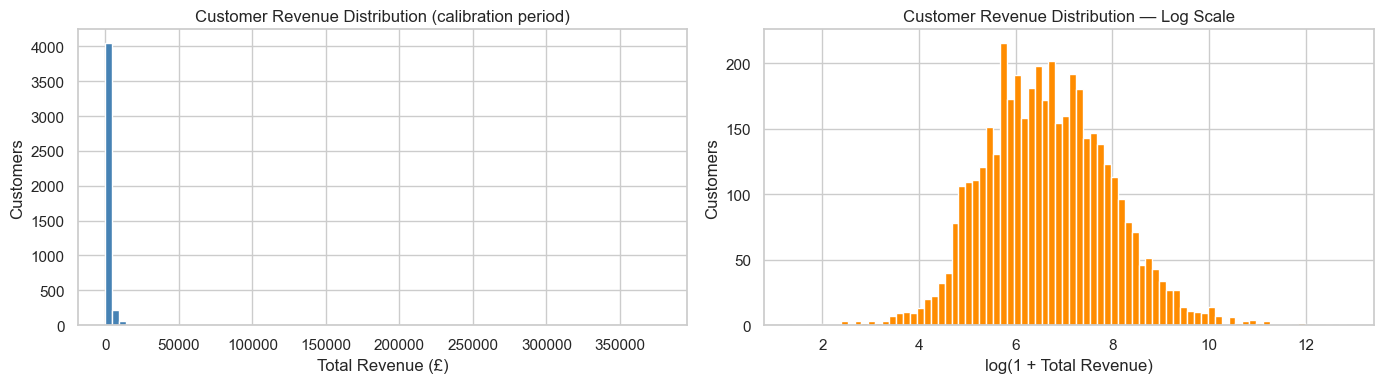

Top 1,155 customers (26.3%) account for 80% of calibration-period revenue  [Pareto check]


In [12]:
# ── Revenue distribution (log scale) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

calib_rev = df_calib.groupby('customer_id')['revenue'].sum()

axes[0].hist(calib_rev, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_ylabel('Customers')
axes[0].set_title('Customer Revenue Distribution (calibration period)')

axes[1].hist(np.log1p(calib_rev), bins=80, color='darkorange', edgecolor='white')
axes[1].set_xlabel('log(1 + Total Revenue)')
axes[1].set_ylabel('Customers')
axes[1].set_title('Customer Revenue Distribution — Log Scale')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_revenue_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# Pareto check: what % of customers drive 80% of revenue?
sorted_rev = calib_rev.sort_values(ascending=False)
cumulative  = sorted_rev.cumsum() / sorted_rev.sum()
n80 = (cumulative <= 0.80).sum()
print(f'Top {n80:,} customers ({n80/len(calib_rev)*100:.1f}%) '
      f'account for 80% of calibration-period revenue  [Pareto check]')

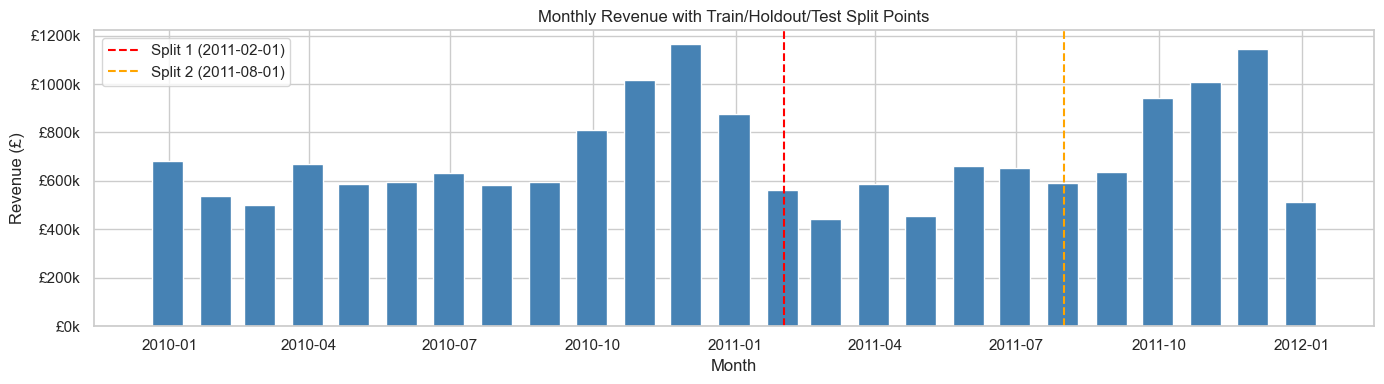

In [13]:
# ── Monthly revenue trend ─────────────────────────────────────────────────────
monthly = (df.set_index('invoicedate')
             .resample('ME')['revenue']
             .sum()
             .reset_index())

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['invoicedate'], monthly['revenue'], color='steelblue',
       width=20, edgecolor='white')
ax.axvline(SPLIT_1, color='red',    linestyle='--', label=f'Split 1 ({SPLIT_1.date()})')
ax.axvline(SPLIT_2, color='orange', linestyle='--', label=f'Split 2 ({SPLIT_2.date()})')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.set_title('Monthly Revenue with Train/Holdout/Test Split Points')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_monthly_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

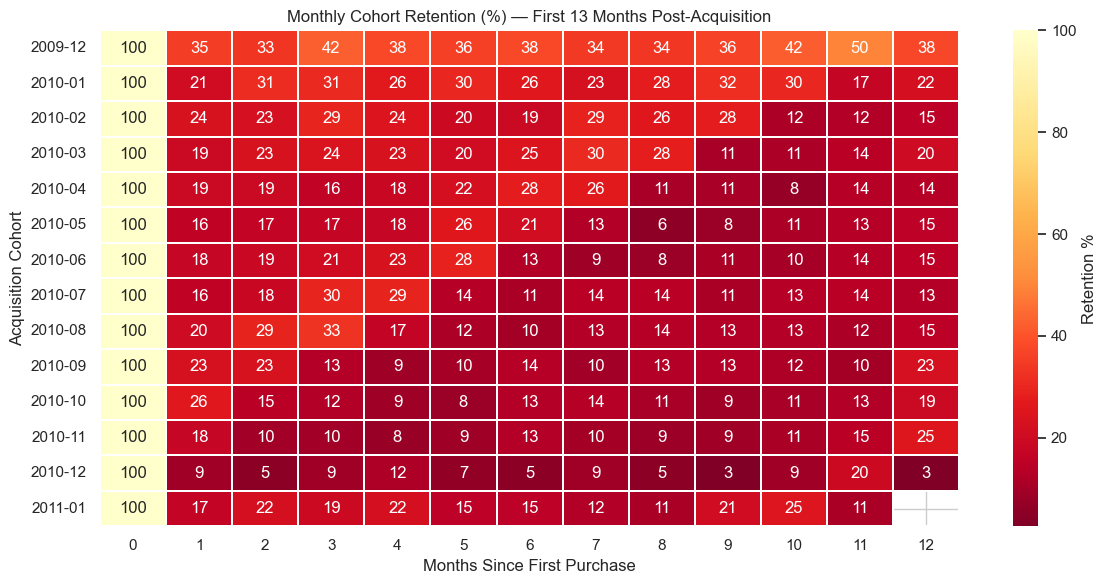

In [14]:
# ── Monthly cohort retention curves ──────────────────────────────────────────
# For each cohort (month of first purchase), track what fraction repurchased
# in each subsequent month.

df['cohort_month'] = df.groupby('customer_id')['invoicedate'].transform('min').dt.to_period('M')
df['invoice_month'] = df['invoicedate'].dt.to_period('M')
df['cohort_index'] = (
    df['invoice_month'].astype(int) - df['cohort_month'].astype(int)
)

cohort_data = (df.groupby(['cohort_month', 'cohort_index'])['customer_id']
                 .nunique()
                 .reset_index())

cohort_pivot = cohort_data.pivot_table(index='cohort_month',
                                        columns='cohort_index',
                                        values='customer_id')

cohort_size = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100

# Plot the first 12 months of retention for cohorts that have full coverage
plot_cohorts = retention_pct.iloc[:14, :13]  # first 14 cohorts, first 13 months

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    plot_cohorts.round(1), annot=True, fmt='.0f',
    cmap='YlOrRd_r', linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Retention %'}
)
ax.set_title('Monthly Cohort Retention (%) — First 13 Months Post-Acquisition')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_cohort_retention.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Customer-Level Feature Engineering

We aggregate the transaction log to one row per customer. All features are computed **from the calibration period only** to avoid any leakage into the holdout or test periods.

Features are organized into five groups:

| Group | Features |
|-------|----------|
| **RFM** | `recency_days`, `frequency`, `monetary_total`, `monetary_avg_basket` |
| **Tenure** | `tenure_days`, `first_purchase_date`, `last_purchase_date` |
| **Behavioral Diversity** | `n_unique_products`, `n_unique_categories_proxy`, `basket_size_avg`, `basket_size_std`, `return_rate` |
| **Temporal Patterns** | `weekend_share`, `interpurchase_time_mean`, `interpurchase_time_max`, `last_vs_avg_gap_ratio` |
| **Country / Price-Tier** | `is_uk`, `avg_unit_price`, `price_tier` |

The **observation date** for recency calculations is `SPLIT_1` (the start of the holdout period) — i.e., we treat that date as "today" from the model's perspective.

In [15]:
# ── Work only from calibration period ────────────────────────────────────────
calib = df_calib.copy()

# Customer-level aggregation
cust_base = calib.groupby('customer_id').agg(
    first_purchase_date = ('invoicedate', 'min'),
    last_purchase_date  = ('invoicedate', 'max'),
    frequency           = ('invoice', 'nunique'),    # distinct invoices
    monetary_total      = ('revenue', 'sum'),
    country             = ('country', lambda x: x.mode()[0])  # most common
).reset_index()

# ── RFM ───────────────────────────────────────────────────────────────────────
cust_base['recency_days'] = (
    OBS_DATE - cust_base['last_purchase_date']
).dt.days

# Repeat buyers only (frequency > 1) have a meaningful recency in BG/NBD terms
cust_base['monetary_avg_basket'] = (
    cust_base['monetary_total'] / cust_base['frequency']
)

# ── Tenure ────────────────────────────────────────────────────────────────────
cust_base['tenure_days'] = (
    cust_base['last_purchase_date'] - cust_base['first_purchase_date']
).dt.days

print('RFM + Tenure features computed.')
print(cust_base[['customer_id','recency_days','frequency','monetary_total',
                  'monetary_avg_basket','tenure_days']].describe())

RFM + Tenure features computed.
       customer_id  recency_days  frequency  monetary_total  \
count    4398.0000     4398.0000  4398.0000       4398.0000   
mean    15352.3147      125.1169     4.6880       2231.9852   
std      1703.8970      105.0007     8.5649       9732.6552   
min     12346.0000        0.0000     1.0000          2.9500   
25%     13883.2500       55.0000     1.0000        312.6575   
50%     15357.0000       90.0000     2.0000        740.2050   
75%     16843.7500      168.0000     5.0000       1846.1425   
max     18287.0000      426.0000   198.0000     376998.9600   

       monetary_avg_basket  tenure_days  
count            4398.0000    4398.0000  
mean              386.9527     146.1812  
std               519.7376     144.5458  
min                 2.9500       0.0000  
25%               185.2038       0.0000  
50%               293.7500     113.0000  
75%               430.6208     276.0000  
max             11880.8400     425.0000  


In [16]:
# ── Behavioral Diversity Features ─────────────────────────────────────────────

# Number of unique products purchased
n_products = calib.groupby('customer_id')['stockcode'].nunique().rename('n_unique_products')

# Proxy for product category diversity: first 2 chars of StockCode
calib['category_proxy'] = calib['stockcode'].astype(str).str[:2]
n_categories = calib.groupby('customer_id')['category_proxy'].nunique().rename('n_unique_categories_proxy')

# Average and std basket size (items per invoice)
basket_stats = (calib.groupby(['customer_id', 'invoice'])['quantity']
                     .sum()
                     .reset_index()
                     .groupby('customer_id')['quantity']
                     .agg(basket_size_avg='mean', basket_size_std='std')
                     .fillna(0))

# Return rate: cancellation rows / (total original + cancellation rows)
# Re-attach customer_id to cancellations for this calc
cancel_counts = (df_cancellations
                 .groupby('customer_id')['invoice']
                 .nunique()
                 .rename('n_cancel_invoices')
                 .reset_index())

cust_base = (cust_base
             .merge(n_products,   on='customer_id', how='left')
             .merge(n_categories, on='customer_id', how='left')
             .merge(basket_stats, on='customer_id', how='left')
             .merge(cancel_counts, on='customer_id', how='left'))

cust_base['n_cancel_invoices'] = cust_base['n_cancel_invoices'].fillna(0)
cust_base['return_rate'] = (
    cust_base['n_cancel_invoices'] /
    (cust_base['frequency'] + cust_base['n_cancel_invoices'])
)

print('Behavioral diversity features computed.')
print(cust_base[['n_unique_products','n_unique_categories_proxy',
                  'basket_size_avg','basket_size_std','return_rate']].describe())

Behavioral diversity features computed.
       n_unique_products  n_unique_categories_proxy  basket_size_avg  \
count          4398.0000                  4398.0000        4398.0000   
mean             66.1630                     7.4695         265.7795   
std              89.4043                     3.9586        1552.3411   
min               1.0000                     1.0000           1.0000   
25%              17.0000                     5.0000          92.0000   
50%              39.0000                     7.0000         157.6250   
75%              82.0000                    10.0000         266.6458   
max            1776.0000                    30.0000       87167.0000   

       basket_size_std  return_rate  
count        4398.0000    4398.0000  
mean          125.5062       0.1686  
std           925.5846       0.2090  
min             0.0000       0.0000  
25%             0.0000       0.0000  
50%            45.6241       0.0000  
75%           120.9328       0.3333  
max    

In [17]:
# ── Temporal Pattern Features ─────────────────────────────────────────────────

# Weekend share (Sat=5, Sun=6)
calib['is_weekend'] = calib['invoicedate'].dt.dayofweek >= 5
weekend_share = (calib.groupby('customer_id')['is_weekend']
                      .mean()
                      .rename('weekend_share'))

# Inter-purchase times (days between consecutive distinct invoices per customer)
invoice_dates = (calib.groupby(['customer_id', 'invoice'])['invoicedate']
                      .min()
                      .reset_index()
                      .sort_values(['customer_id', 'invoicedate']))

invoice_dates['ipt'] = (invoice_dates
                        .groupby('customer_id')['invoicedate']
                        .diff()
                        .dt.days)

ipt_stats = (invoice_dates
             .dropna(subset=['ipt'])
             .groupby('customer_id')['ipt']
             .agg(interpurchase_time_mean='mean',
                  interpurchase_time_max='max'))

# Last gap vs. average gap ratio: a high ratio signals the customer may be drifting away
last_gap = (invoice_dates
            .groupby('customer_id')
            .apply(lambda g: g['ipt'].dropna().iloc[-1] if len(g['ipt'].dropna()) > 0 else np.nan)
            .rename('last_gap_days'))

ipt_stats = ipt_stats.join(last_gap)
ipt_stats['last_vs_avg_gap_ratio'] = (
    ipt_stats['last_gap_days'] / (ipt_stats['interpurchase_time_mean'] + 1e-6)
)

cust_base = (cust_base
             .merge(weekend_share, on='customer_id', how='left')
             .merge(ipt_stats.reset_index(), on='customer_id', how='left'))

# For one-time buyers, inter-purchase time is undefined; set to NaN sentinel
# (downstream models will either impute or use an indicator)
print('Temporal pattern features computed.')
print(cust_base[['weekend_share','interpurchase_time_mean',
                  'interpurchase_time_max','last_vs_avg_gap_ratio']].describe())

Temporal pattern features computed.
       weekend_share  interpurchase_time_mean  interpurchase_time_max  \
count      4398.0000                2963.0000               2963.0000   
mean          0.1521                  71.4485                111.4188   
std           0.2910                  62.5843                 74.0379   
min           0.0000                   0.0000                  0.0000   
25%           0.0000                  29.7917                 57.0000   
50%           0.0000                  53.4286                 97.0000   
75%           0.1599                  92.0000                151.0000   
max           1.0000                 417.0000                417.0000   

       last_vs_avg_gap_ratio  
count              2963.0000  
mean                  0.9821  
std                   0.7402  
min                   0.0000  
25%                   0.5137  
50%                   1.0000  
75%                   1.2258  
max                  11.1008  


In [18]:
# ── Country & Price-Tier Features ────────────────────────────────────────────

# UK indicator (vast majority of customers)
cust_base['is_uk'] = (cust_base['country'].str.upper() == 'UNITED KINGDOM').astype(int)

# Average unit price paid by the customer
avg_price = (calib.groupby('customer_id')['price']
                  .mean()
                  .rename('avg_unit_price'))
cust_base = cust_base.merge(avg_price, on='customer_id', how='left')

# Price tier (Low / Mid / High) based on calibration-period quartiles
price_labels = ['Low', 'Mid', 'High']
cust_base['price_tier'] = pd.qcut(
    cust_base['avg_unit_price'], q=3, labels=price_labels
).astype(str)

print('Country & price-tier features computed.')
print(cust_base['price_tier'].value_counts().to_string())
print(f'UK customers: {cust_base["is_uk"].sum():,} / {len(cust_base):,}')

Country & price-tier features computed.
price_tier
High    1466
Low     1466
Mid     1466
UK customers: 4,043 / 4,398


---
## 7. Supervised Learning Target Labels

For the gradient-boosting churn model, we need a binary label:

- **`repurchase_90d`** — Did the customer make at least one purchase in the 90 days after `SPLIT_1`?
- **`repurchase_180d`** — Same check over 180 days (the holdout window spans ~180 days)

Customers who *do not* repurchase are our "churned" label. This is the standard proxy for non-contractual churn.

In [19]:
# Customers who purchased in the holdout window
holdout_customers_90d = set(
    df_holdout[df_holdout['invoicedate'] < SPLIT_1 + pd.Timedelta(days=90)]
    ['customer_id']
)
holdout_customers_180d = set(df_holdout['customer_id'])

# Only label customers who were seen in calibration
calib_customers = set(cust_base['customer_id'])

cust_base['repurchase_90d']  = cust_base['customer_id'].isin(holdout_customers_90d).astype(int)
cust_base['repurchase_180d'] = cust_base['customer_id'].isin(holdout_customers_180d).astype(int)

print('=== Target Label Distribution ===')
for col in ['repurchase_90d', 'repurchase_180d']:
    vc = cust_base[col].value_counts()
    pos_rate = vc.get(1, 0) / len(cust_base) * 100
    print(f'{col}:  repurchased={vc.get(1,0):,}  ({pos_rate:.1f}%)  '
          f'churned={vc.get(0,0):,}  ({100-pos_rate:.1f}%)')

=== Target Label Distribution ===
repurchase_90d:  repurchased=1,467  (33.4%)  churned=2,931  (66.6%)
repurchase_180d:  repurchased=2,048  (46.6%)  churned=2,350  (53.4%)


---
## 8. Handling Missing Values in the Feature Table

Some features are undefined for one-time buyers (e.g., inter-purchase time). We document each case and apply a principled strategy:

| Feature | Missing case | Strategy |
|---------|-------------|----------|
| `interpurchase_time_mean` | Only 1 invoice | Fill with `recency_days` (the only purchase gap we have) |
| `interpurchase_time_max` | Same | Same fill |
| `last_gap_days` | Same | Same fill |
| `last_vs_avg_gap_ratio` | Same | Fill with 1.0 (gap equals average) |
| `basket_size_std` | Only 1 invoice | Fill with 0 (no variance) |

In [20]:
# ── Report before imputation ──────────────────────────────────────────────────
missing_features = cust_base.isnull().sum()
missing_features = missing_features[missing_features > 0]
print('Missing values before imputation:')
print(missing_features.to_string())

# ── Impute ────────────────────────────────────────────────────────────────────
one_time_mask = cust_base['frequency'] == 1

for col in ['interpurchase_time_mean', 'interpurchase_time_max', 'last_gap_days']:
    cust_base.loc[one_time_mask, col] = cust_base.loc[one_time_mask, 'recency_days']

cust_base['last_vs_avg_gap_ratio'] = cust_base['last_vs_avg_gap_ratio'].fillna(1.0)
cust_base['basket_size_std']       = cust_base['basket_size_std'].fillna(0)

# Any remaining NaNs
remaining = cust_base.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print('\n✓ No remaining missing values in feature table.')
else:
    print('\nRemaining missing values:')
    print(remaining.to_string())

Missing values before imputation:
interpurchase_time_mean    1435
interpurchase_time_max     1435
last_gap_days              1435
last_vs_avg_gap_ratio      1435

✓ No remaining missing values in feature table.


---
## 9. Final Feature Table Summary

In [21]:
print('=== Customer Feature Table ===')
print(f'  Shape : {cust_base.shape}')
print(f'  Rows  : {len(cust_base):,} unique customers')
print(f'  Cols  : {cust_base.shape[1]}')
print()

print('Columns:')
for col in cust_base.columns:
    print(f'  {col:<35} {str(cust_base[col].dtype):<12} '
          f'null={cust_base[col].isnull().sum()}')

print()
cust_base.describe().T

=== Customer Feature Table ===
  Shape : (4398, 25)
  Rows  : 4,398 unique customers
  Cols  : 25

Columns:
  customer_id                         float64      null=0
  first_purchase_date                 datetime64[ns] null=0
  last_purchase_date                  datetime64[ns] null=0
  frequency                           int64        null=0
  monetary_total                      float64      null=0
  country                             object       null=0
  recency_days                        int64        null=0
  monetary_avg_basket                 float64      null=0
  tenure_days                         int64        null=0
  n_unique_products                   int64        null=0
  n_unique_categories_proxy           int64        null=0
  basket_size_avg                     float64      null=0
  basket_size_std                     float64      null=0
  n_cancel_invoices                   float64      null=0
  return_rate                         float64      null=0
  weekend_share   

,count,mean,min,25%,50%,75%,max,std
customer_id,4398.0000,15352.3147,12346.0000,13883.2500,15357.0000,16843.7500,18287.0000,1703.8970
first_purchase_date,4398,2010-05-04 21:59:40.941336832,2009-12-01 07:45:00,2010-01-17 14:51:30,2010-04-08 09:25:00,2010-08-29 11:45:45,2011-01-31 14:18:00,NaN
last_purchase_date,4398,2010-09-28 10:25:37.789904384,2009-12-01 10:49:00,2010-08-16 12:15:45,2010-11-02 11:57:00,2010-12-07 15:41:00,2011-01-31 16:59:00,NaN
frequency,4398.0000,4.6880,1.0000,1.0000,2.0000,5.0000,198.0000,8.5649
monetary_total,4398.0000,2231.9852,2.9500,312.6575,740.2050,1846.1425,376998.9600,9732.6552
recency_days,4398.0000,125.1169,0.0000,55.0000,90.0000,168.0000,426.0000,105.0007
monetary_avg_basket,4398.0000,386.9527,2.9500,185.2038,293.7500,430.6208,11880.8400,519.7376
tenure_days,4398.0000,146.1812,0.0000,0.0000,113.0000,276.0000,425.0000,144.5458
n_unique_products,4398.0000,66.1630,1.0000,17.0000,39.0000,82.0000,1776.0000,89.4043
n_unique_categories_proxy,4398.0000,7.4695,1.0000,5.0000,7.0000,10.0000,30.0000,3.9586


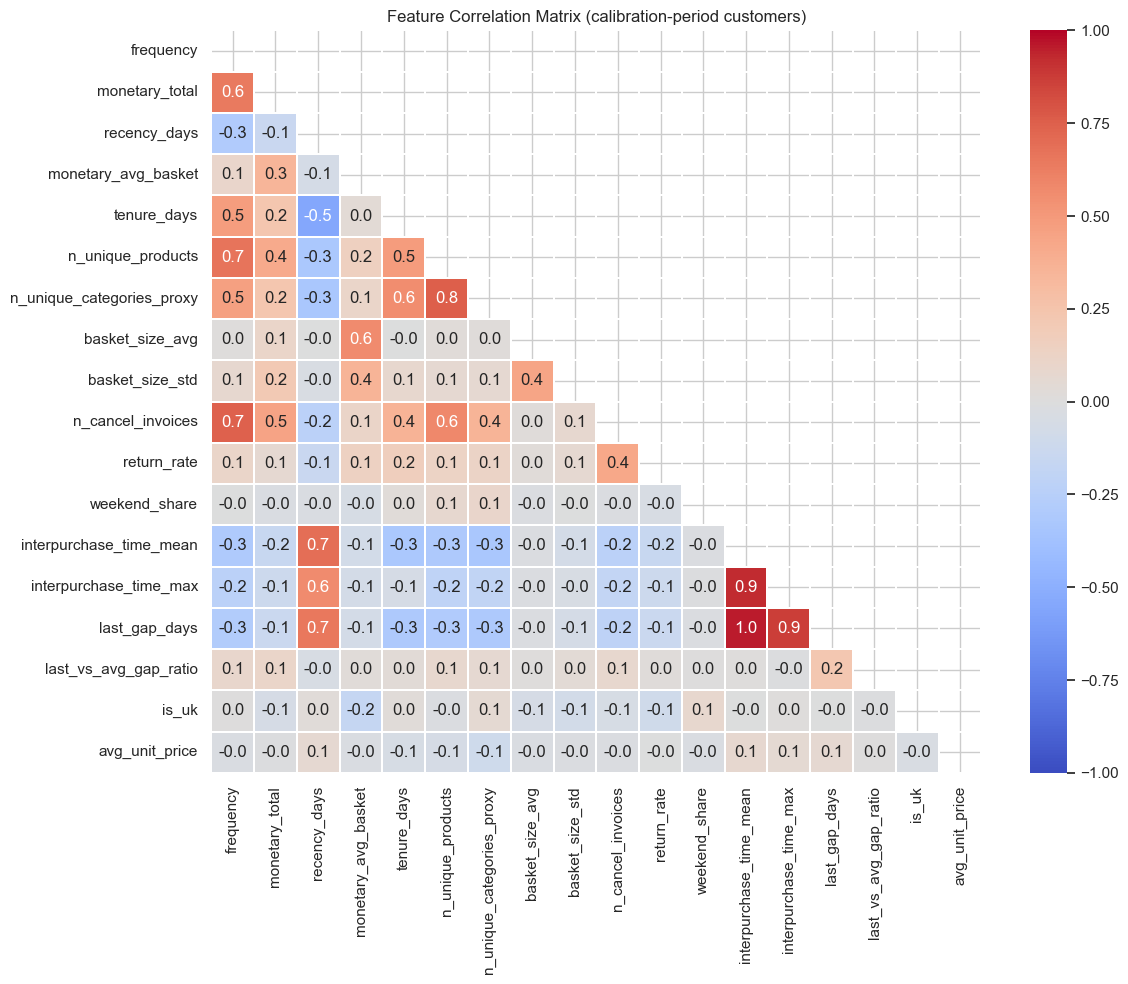

In [22]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
numeric_cols = cust_base.select_dtypes(include=np.number).columns.tolist()
# Exclude date-derived object cols and targets for this viz
exclude = ['customer_id', 'repurchase_90d', 'repurchase_180d']
feat_cols = [c for c in numeric_cols if c not in exclude]

corr = cust_base[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.1f', linewidths=0.3,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix (calibration-period customers)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_feature_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Export

We save two files:

1. **`transactions_clean.csv`** — The full cleaned transaction log with period tags. Used by BG/NBD fitting and exploratory cohort analysis.
2. **`customer_features.csv`** — The customer-level feature table. Used by the supervised churn model and the CLV segmentation.

A brief data dictionary is printed for each.

In [23]:
# ── Transactions ──────────────────────────────────────────────────────────────
txn_path = os.path.join(OUTPUT_DIR, 'transactions_clean.csv')
df.to_csv(txn_path, index=False)
print(f'✓ Saved: {txn_path}  ({len(df):,} rows × {df.shape[1]} cols)')

# ── Customer features ─────────────────────────────────────────────────────────
feat_path = os.path.join(OUTPUT_DIR, 'customer_features.csv')

# Drop intermediate date columns that aren't needed downstream
# (the model notebooks will use recency_days, not raw timestamps)
export_cols = [c for c in cust_base.columns 
               if c not in ['first_purchase_date', 'last_purchase_date', 
                             'cohort_month', 'invoice_month', 'cohort_index']]
cust_export = cust_base[export_cols]
cust_export.to_csv(feat_path, index=False)
print(f'✓ Saved: {feat_path}  ({len(cust_export):,} rows × {cust_export.shape[1]} cols)')

print()
print('=== Data Dictionary: customer_features.csv ===')
field_descriptions = {
    'customer_id'              : 'Unique customer identifier',
    'frequency'                : 'Number of distinct invoices in calibration period',
    'monetary_total'           : 'Total revenue (£) in calibration period',
    'country'                  : 'Most frequent country of purchase',
    'recency_days'             : 'Days from last purchase to observation date (SPLIT_1)',
    'monetary_avg_basket'      : 'Average revenue per invoice',
    'tenure_days'              : 'Days between first and last purchase',
    'n_unique_products'        : 'Number of distinct StockCodes purchased',
    'n_unique_categories_proxy': 'Number of distinct 2-char StockCode prefixes (category proxy)',
    'basket_size_avg'          : 'Average total items per invoice',
    'basket_size_std'          : 'Std dev of items per invoice (0 for one-time buyers)',
    'n_cancel_invoices'        : 'Number of cancellation invoices attributed to this customer',
    'return_rate'              : 'Cancellations / (purchases + cancellations)',
    'weekend_share'            : 'Fraction of transactions on Saturday or Sunday',
    'interpurchase_time_mean'  : 'Mean days between consecutive purchases',
    'interpurchase_time_max'   : 'Max days between consecutive purchases',
    'last_gap_days'            : 'Days between second-to-last and last purchase',
    'last_vs_avg_gap_ratio'    : 'last_gap_days / interpurchase_time_mean (>1 signals drift)',
    'is_uk'                    : '1 if customer is UK-based, 0 otherwise',
    'avg_unit_price'           : 'Average unit price paid across all items',
    'price_tier'               : 'Tertile price tier: Low / Mid / High',
    'repurchase_90d'           : 'TARGET — 1 if purchased within 90 days of SPLIT_1',
    'repurchase_180d'          : 'TARGET — 1 if purchased within 180 days of SPLIT_1 (holdout window)',
}
for col in cust_export.columns:
    desc = field_descriptions.get(col, '—')
    print(f'  {col:<35} {desc}')

✓ Saved: ../data/processed/transactions_clean.csv  (802,932 rows × 13 cols)
✓ Saved: ../data/processed/customer_features.csv  (4,398 rows × 23 cols)

=== Data Dictionary: customer_features.csv ===
  customer_id                         Unique customer identifier
  frequency                           Number of distinct invoices in calibration period
  monetary_total                      Total revenue (£) in calibration period
  country                             Most frequent country of purchase
  recency_days                        Days from last purchase to observation date (SPLIT_1)
  monetary_avg_basket                 Average revenue per invoice
  tenure_days                         Days between first and last purchase
  n_unique_products                   Number of distinct StockCodes purchased
  n_unique_categories_proxy           Number of distinct 2-char StockCode prefixes (category proxy)
  basket_size_avg                     Average total items per invoice
  basket_size_std  

---
## 11. Summary & Next Steps

### What we did

| Step | Result |
|------|--------|
| Loaded raw data | ~1M rows across two sheets |
| Dropped missing Customer IDs | ~25% of rows removed (guest sessions) |
| Removed cancellations | ~2% removed; retained separately for return_rate feature |
| Removed non-product codes | <1% removed |
| Removed non-positive Qty/Price | <1% removed |
| Cleaned transactions | Saved to `transactions_clean.csv` |
| Engineered 20 customer-level features | RFM, tenure, diversity, temporal, geo/price |
| Defined time-based splits | Calibration / Holdout / Test — zero leakage |
| Created supervised targets | `repurchase_90d`, `repurchase_180d` |
| Exported feature table | Saved to `customer_features.csv` |

### Key observations
- Revenue is **highly right-skewed** — the top ~20% of customers drive ~80% of revenue (Pareto principle confirmed)
- **Cohort retention drops sharply** after month 1, confirming this is a non-contractual churn problem
- **Class imbalance** is present in both targets — this will be handled with class weighting and PR-AUC reporting in the supervised model notebook
- **One-time buyers** make up a meaningful fraction and have undefined inter-purchase features — we flagged these and applied principled imputation

### Discussion questions for mentor call
1. What cleaning steps did we perform? → Documented above in Section 3 with row counts at each step
2. How did we deal with missing values? → Missing Customer IDs dropped; feature-level missingness imputed with documented rationale
3. Were there outliers, and how did we handle them? → Non-positive quantities and prices removed; high-revenue customers retained (they are real signal, not noise)

### Next notebook
**`02_clv_probabilistic.ipynb`** — Fit BG/NBD and Gamma-Gamma models on `transactions_clean.csv`, validate against the holdout window, and generate per-customer probability-alive and expected-CLV estimates.